In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
# Topic 158 | Introduction to Long Short-Term Memory (LSTM)
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input

print("=== INITIALIZING LONG SHORT-TERM MEMORY ENGINE ===")

# Model Tensor Setup: 20 days time steps tracking with 4 financial features
time_steps = 20
features_per_step = 4

model = Sequential([
    # Input Node gatekeeper
    Input(shape=(time_steps, features_per_step)),
    
    # LSTM Layer: 64 hidden units (Internal cell and hidden memory architecture)
    # return_sequences=False ka matlab hai hume sirf pure sequence ka end context chahiye
    LSTM(units=64, return_sequences=False, activation='tanh', name='LSTM_Core_Cell'),
    
    # Dense Projection Head for binary decision layout
    Dense(units=1, activation='sigmoid', name='Prediction_Head')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("\n--- LSTM Model Tensor Topology Summary ---")
model.summary()

E0000 00:00:1781940739.761759      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781940739.827630      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781940740.341961      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781940740.342003      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781940740.342006      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781940740.342009      16 computation_placer.cc:177] computation placer already registered. Please check linka

=== INITIALIZING LONG SHORT-TERM MEMORY ENGINE ===

--- LSTM Model Tensor Topology Summary ---


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ LSTM_Core_Cell (LSTM)           │ (None, 64)             │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Prediction_Head (Dense)         │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,729 (69.25 KB)

 Trainable params: 17,729 (69.25 KB)

 Non-trainable params: 0 (0.00 B)

In [3]:
# Topic 159 | LSTM - Building an LSTM Model with TensorFlow/Keras
import os
# Internal backend infrastructure logs ko mute karne ke liye
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input

print("=== DEPLOYING INDUSTRIAL LSTM MODEL PRODUCTION ENGINE ===")

# 1. Synthetic Weather Sequence Generation (Time-Series Simulation)
# 500 total samples, 14 days historic window tracking, 3 features per day
X_train = np.random.randn(500, 14, 3)
# Target variable: Continuous value representing the next day's temperature
y_train = np.random.randn(500, 1)

print(f"Input Sequence Tensor Shape (3D): {X_train.shape}")
print(f"Target Continuous Matrix Shape : {y_train.shape}\n")

# ------------------------------------------------------------------
# STEP 2: ARCHITECTING A DEEP LSTM STRUCTURE
# ------------------------------------------------------------------
model = Sequential([
    # Standard Gatekeeper matching (Time_Steps=14, Features=3)
    Input(shape=(14, 3)),
    
    # Layer 1: Stacked LSTM layer. Must set return_sequences=True to feed the next LSTM layer
    LSTM(units=50, return_sequences=True, activation='tanh', name='LSTM_Layer_1'),
    Dropout(0.2, name='Dropout_1'), # Prevents network from overfitting on training patterns
    
    # Layer 2: Final LSTM layer. return_sequences=False because we only want the final aggregated context
    LSTM(units=30, return_sequences=False, activation='tanh', name='LSTM_Layer_2'),
    Dropout(0.2, name='Dropout_2'),
    
    # Dense Regression Output Layer (1 Neuron, No activation function for raw numeric tracking)
    Dense(units=1, name='Regression_Output')
])

# ------------------------------------------------------------------
# STEP 3: COMPILATION (Adam Optimizer with MSE Loss)
# ------------------------------------------------------------------
# Continuous prediction ke liye loss standard hamesha Mean Squared Error (MSE) hota hai
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mean_squared_error',
    metrics=['mae'] # Mean Absolute Error to audit human-readable deviation
)

print("--- LSTM Tensor Topology Structural Summary ---")
model.summary()

# ------------------------------------------------------------------
# STEP 4: TRAINING EXECUTION PASS
# ------------------------------------------------------------------
print("\nLaunching training loop over 10 epochs...")
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1, # 10% data live check up ke liye validation mein rakhein
    verbose=1
)

print("\nLSTM Pipeline model successfully compiled and trained without any breakdown!")

=== DEPLOYING INDUSTRIAL LSTM MODEL PRODUCTION ENGINE ===
Input Sequence Tensor Shape (3D): (500, 14, 3)
Target Continuous Matrix Shape : (500, 1)

--- LSTM Tensor Topology Structural Summary ---


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ LSTM_Layer_1 (LSTM)             │ (None, 14, 50)         │        10,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_1 (Dropout)             │ (None, 14, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LSTM_Layer_2 (LSTM)             │ (None, 30)             │         9,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_2 (Dropout)             │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Regression_Output (Dense)       │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,551 (80.28 KB)

 Trainable params: 20,551 (80.28 KB)

 Non-trainable params: 0 (0.00 B)


Launching training loop over 10 epochs...
Epoch 1/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - loss: 0.9586 - mae: 0.7689 - val_loss: 0.7979 - val_mae: 0.7718
Epoch 2/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.9452 - mae: 0.7612 - val_loss: 0.8038 - val_mae: 0.7729
Epoch 3/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.9454 - mae: 0.7639 - val_loss: 0.8143 - val_mae: 0.7769
Epoch 4/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.9434 - mae: 0.7620 - val_loss: 0.8054 - val_mae: 0.7761
Epoch 5/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.9374 - mae: 0.7630 - val_loss: 0.8092 - val_mae: 0.7784
Epoch 6/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.9334 - mae: 0.7609 - val_loss: 0.8200 - val_mae: 0.7826
Epoch 7/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.9389 - mae: 0.7654 - val_loss: 0.8237 - val_mae: 0.7831
Epoch 8/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.9302 - mae: 0.7608 - val_loss: 0.8237 - val_mae: 0.7838
Epoch 9/10
15/15 ━━━━

=== COMPUTER VISION MATHEMATICAL TENSOR SIMULATION ===
Image Tensor Rank (Dimensions): 3D
Image Tensor Spatial Shape   : (100, 100, 3) -> (Height, Width, Channels)
Data Type in Memory          : uint8 (Unsigned 8-bit Integer)


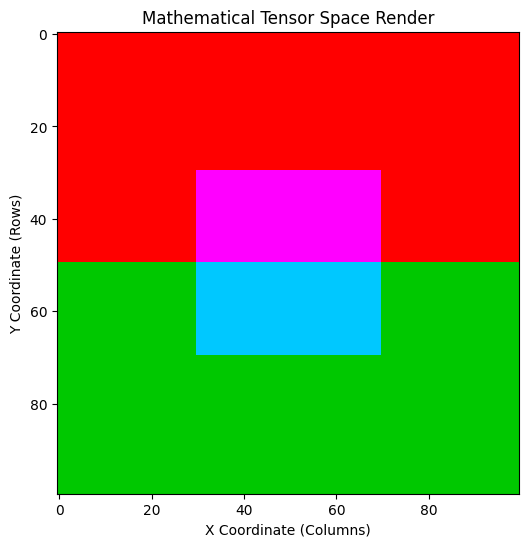

In [4]:
# Topic 160 | Computer Vision - Mathematical Foundations
import numpy as np
import matplotlib.pyplot as plt

print("=== COMPUTER VISION MATHEMATICAL TENSOR SIMULATION ===")

# 1. Create a raw 3D Tensor for a synthetic image (100x100 pixels, 3 channels)
# Shuru mein poori image ko black (zeros) kar dete hain
image_tensor = np.zeros((100, 100, 3), dtype=np.uint8)

# 2. Mathematical Coordinate Vector Assignment
# Red channel (Index 0) par top half matrix ko high intensity pixels assign karte hain
image_tensor[0:50, :, 0] = 255  # Top 50 rows mein Red channel full bright

# Green channel (Index 1) par bottom half matrix ko light values dete hain
image_tensor[50:100, :, 1] = 200 # Bottom 50 rows mein Green channel active

# Blue channel (Index 2) par center mein ek custom patch banate hain
image_tensor[30:70, 30:70, 2] = 255 # Center grid square box turns Blue integrated

# ------------------------------------------------------------------
# 3. TRANSFORMATION & MATRIX AUDIT
# ------------------------------------------------------------------
print(f"Image Tensor Rank (Dimensions): {image_tensor.ndim}D")
print(f"Image Tensor Spatial Shape   : {image_tensor.shape} -> (Height, Width, Channels)")
print(f"Data Type in Memory          : {image_tensor.dtype} (Unsigned 8-bit Integer)")

# Visualizing the raw matrix transformation
plt.figure(figsize=(6, 6))
plt.imshow(image_tensor)
plt.title('Mathematical Tensor Space Render', fontsize=12)
plt.xlabel('X Coordinate (Columns)')
plt.ylabel('Y Coordinate (Rows)')
plt.grid(False)
plt.show()

=== RUNNING COMPUTER VISION FILTERING ENGINE ===


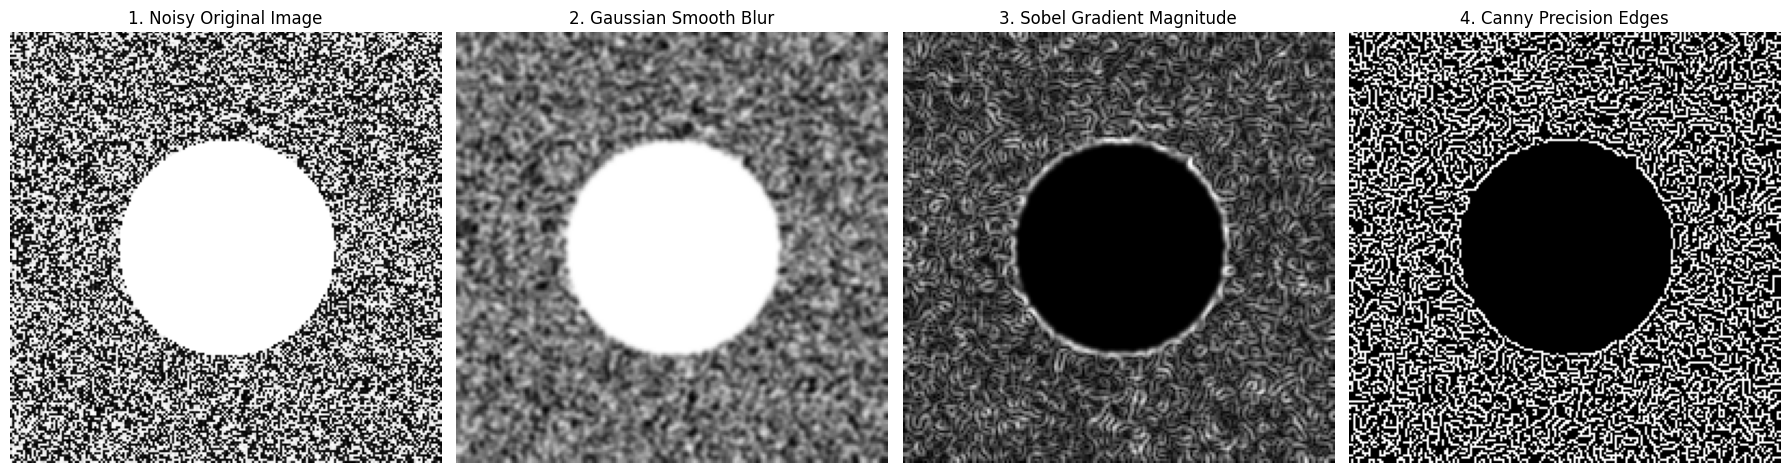

CV Pipeline completed successfully! Notice how Canny gives a sharp, clean border line.


In [5]:
# Topic 161 | Computer Vision - Edge Detection & Filtering Techniques
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import cv2
import numpy as np
import matplotlib.pyplot as plt

print("=== RUNNING COMPUTER VISION FILTERING ENGINE ===")

# 1. Fake image generate karte hain: Ek dark background par white circle
image = np.zeros((200, 200), dtype=np.uint8)
cv2.circle(image, (100, 100), 50, 255, -1) # Center (100,100), Radius 50, Color White

# Image mein thoda noise add karte hain simulation ke liye
noise = np.random.normal(0, 20, image.shape).astype(np.uint8)
noisy_image = cv2.add(image, noise)

# ------------------------------------------------------------------
# 2. APPLYING FILTERS & EDGE DETECTORS
# ------------------------------------------------------------------
# A. Gaussian Blur (5x5 kernel size, sigma=0)
blurred_image = cv2.GaussianBlur(noisy_image, (5, 5), 0)

# B. Sobel Edge Detection (on blurred image for stability)
sobel_x = cv2.Sobel(blurred_image, cv2.CV_64F, 1, 0, ksize=3) # Horizontal
sobel_y = cv2.Sobel(blurred_image, cv2.CV_64F, 0, 1, ksize=3) # Vertical
sobel_combined = cv2.magnitude(sobel_x, sobel_y)             # Total Gradient

# C. Canny Edge Detection (Threshold Low=50, High=150)
canny_edges = cv2.Canny(blurred_image, 50, 150)

# ------------------------------------------------------------------
# 3. VISUALIZING THE MATRIX TRANSFORMATION
# ------------------------------------------------------------------
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

axes[0].imshow(noisy_image, cmap='gray')
axes[0].set_title('1. Noisy Original Image')
axes[0].axis('off')

axes[1].imshow(blurred_image, cmap='gray')
axes[1].set_title('2. Gaussian Smooth Blur')
axes[1].axis('off')

axes[2].imshow(sobel_combined, cmap='gray')
axes[2].set_title('3. Sobel Gradient Magnitude')
axes[2].axis('off')

axes[3].imshow(canny_edges, cmap='gray')
axes[3].set_title('4. Canny Precision Edges')
axes[3].axis('off')

plt.tight_layout()
plt.show()

print("CV Pipeline completed successfully! Notice how Canny gives a sharp, clean border line.")

=== EXECUTING MORPHOLOGICAL ENGINE ===


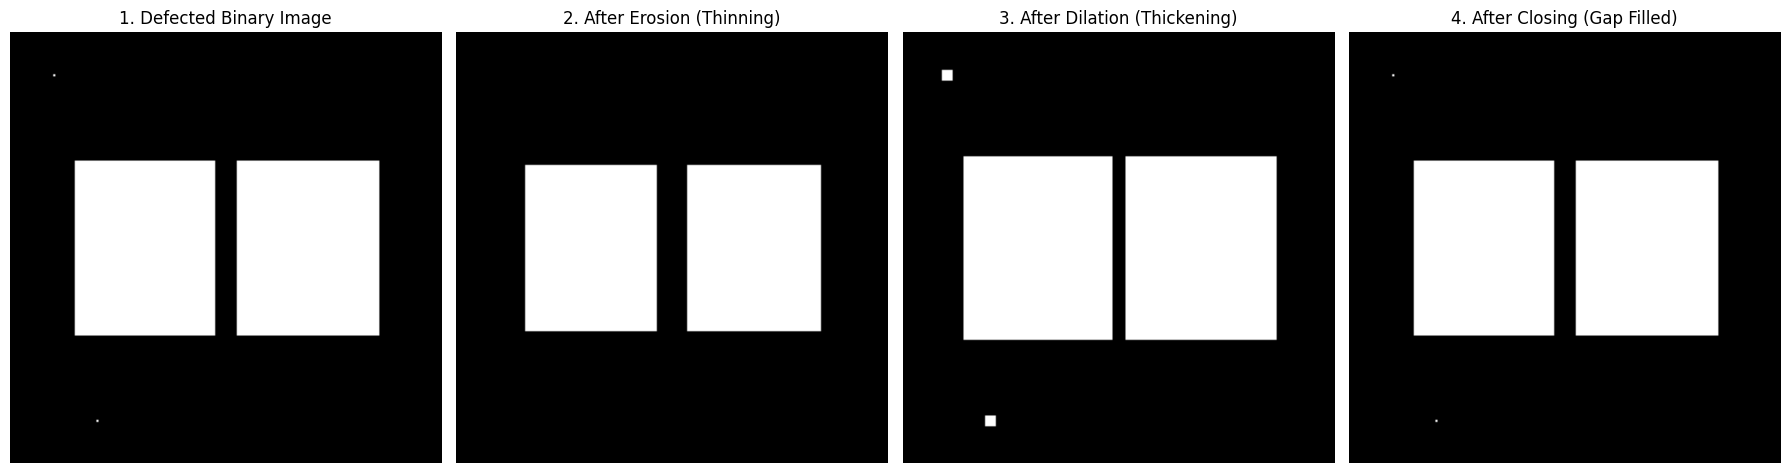

Morphological transformations rendered successfully!


In [6]:
# Topic 162 | Computer Vision - Morphological Operations (Erosion and Dilation)
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import cv2
import numpy as np
import matplotlib.pyplot as plt

print("=== EXECUTING MORPHOLOGICAL ENGINE ===")

# 1. Fake Binary Image generate karte hain: Ek central white block jisme text jaisa gap ho
image = np.zeros((200, 200), dtype=np.uint8)
cv2.rectangle(image, (30, 60), (170, 140), 255, -1)

# Synthetic defect 1: Central line gap (Broken shape)
image[:, 95:105] = 0

# Synthetic defect 2: Random salt noise (isolated background dots)
image[20, 20] = 255
image[180, 40] = 255

# 2. Creating the Structuring Element (5x5 Rectangular Kernel)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))

# ------------------------------------------------------------------
# 3. APPLYING MORPHOLOGICAL OPERATIONS
# ------------------------------------------------------------------
# A. Erosion: Background noise dots ko saaf karega par central gap barh jayega
eroded_image = cv2.erode(image, kernel, iterations=1)

# B. Dilation: Central gap ko bhar dega par background noise ko mota kar dega
dilated_image = cv2.dilate(image, kernel, iterations=1)

# C. Closing: First Dilate then Erode (Gap bharega bina background noise barhaye)
closing_image = cv2.morphologyEx(image, cv2.MORPH_CLOSE, kernel)

# ------------------------------------------------------------------
# 4. DASHBOARD VISUALIZATION
# ------------------------------------------------------------------
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

axes[0].imshow(image, cmap='gray')
axes[0].set_title('1. Defected Binary Image')
axes[0].axis('off')

axes[1].imshow(eroded_image, cmap='gray')
axes[1].set_title('2. After Erosion (Thinning)')
axes[1].axis('off')

axes[2].imshow(dilated_image, cmap='gray')
axes[2].set_title('3. After Dilation (Thickening)')
axes[2].axis('off')

axes[3].imshow(closing_image, cmap='gray')
axes[3].set_title('4. After Closing (Gap Filled)')
axes[3].axis('off')

plt.tight_layout()
plt.show()

print("Morphological transformations rendered successfully!")